Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [1]:
library('tidymodels')
library('broom')
library('yardstick')


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.9     ✔ recipes      1.3.1
✔ dials        1.4.2     ✔ rsample      1.3.1
✔ dplyr        1.1.4     ✔ tailor       0.1.0
✔ ggplot2      3.5.2     ✔ tidyr        1.3.1
✔ infer        1.0.9     ✔ tune         2.0.0
✔ modeldata    1.5.1     ✔ workflows    1.3.0
✔ parsnip      1.3.3     ✔ workflowsets 1.1.1
✔ purrr        1.1.0     ✔ yardstick    1.3.2

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [3]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [4]:
diabetes_train |> glimpse()


Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 10, 4, 10, 1, 3, 1, 13, 5, 3, 3, 7, 1, …
$ Glucose                  <dbl> 85, 89, 115, 110, 139, 103, 126, 97, 145, 109…
$ BloodPressure            <dbl> 66, 66, 0, 92, 80, 30, 88, 66, 82, 75, 58, 64…
$ SkinThickness            <dbl> 29, 23, 0, 0, 0, 38, 41, 15, 19, 26, 11, 25, …
$ Insulin                  <dbl> 0, 94, 0, 0, 0, 83, 235, 140, 110, 0, 54, 70,…
$ BMI                      <dbl> 26.6, 28.1, 35.3, 37.6, 27.1, 43.3, 39.3, 23.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.134, 0.191, 1.441, 0.183, 0.7…
$ Age                      <dbl> 31, 21, 29, 30, 57, 33, 27, 22, 57, 60, 22, 2…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:** Outcome, because it is a binary categorical variable. 

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     |   Plasma glucose concentration a 2 hours in an oral glucose tolerance test          |
| BMI         |       Body mass index (weight in kg/(height in m)^2)      |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

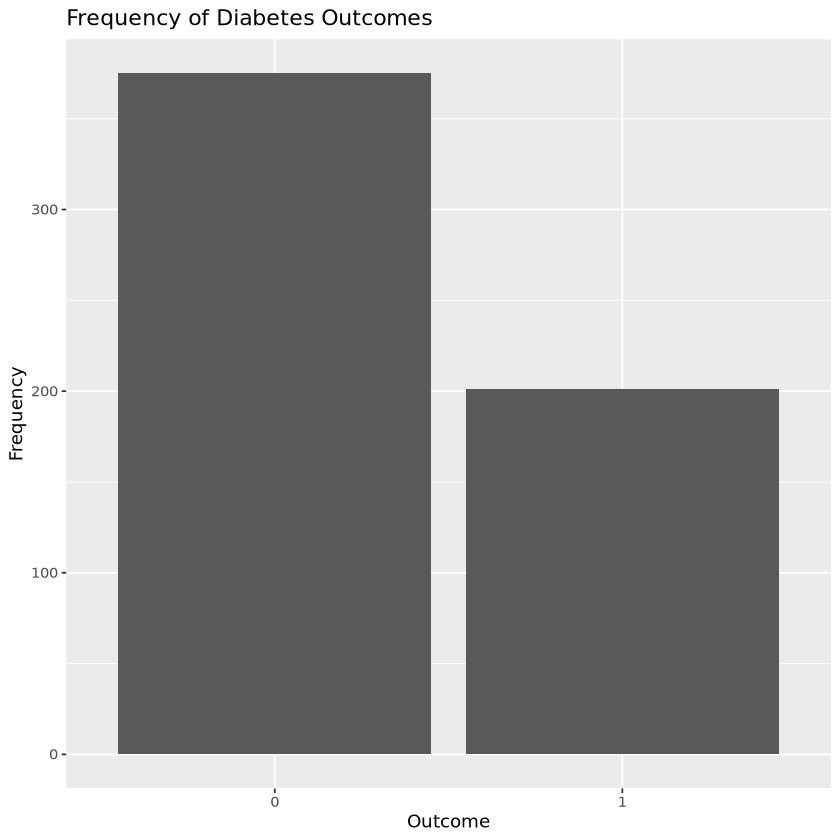

In [5]:
library(ggplot2)

ggplot(diabetes_train, aes(x = Outcome)) +
  geom_bar() +
  labs(
    title = "Frequency of Diabetes Outcomes",
    x = "Outcome",
    y = "Frequency"
  )

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:** No, the dataset is imbalanced because the number of observations with Outcome that is 0 is much larger than the number with Outcome with 1. Therefore, the two outcome classes do not have equal counts.

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [6]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,115.0
0,BMI,35.3


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

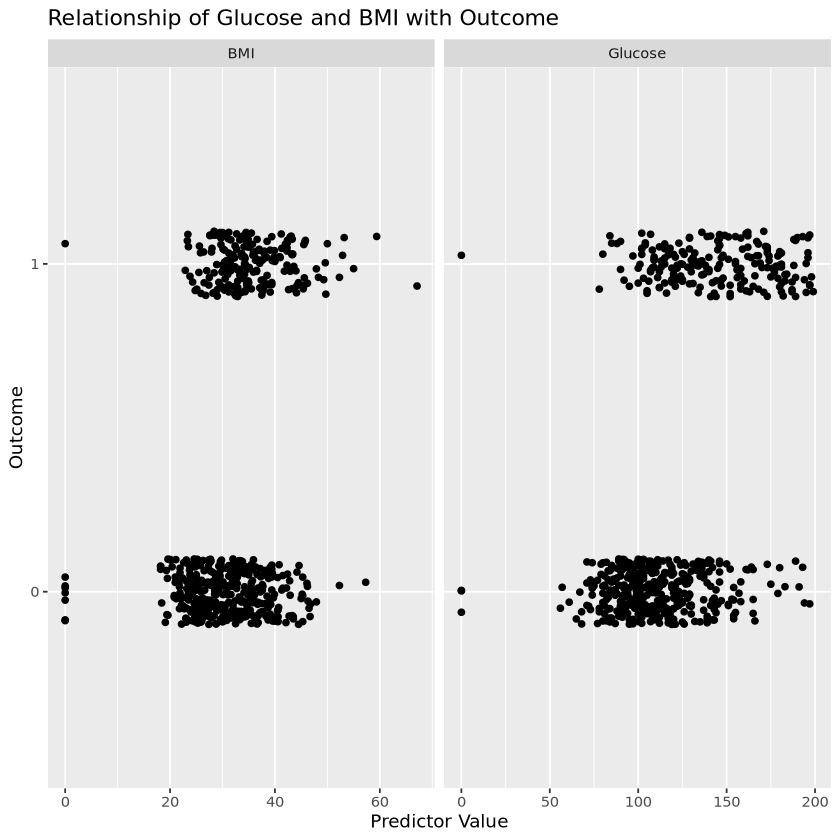

In [7]:
ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter(height = 0.1, width = 0) +
  facet_wrap(~name, ncol = 2, scales = "free_x") +
  labs(
    title = "Relationship of Glucose and BMI with Outcome",
    x = "Predictor Value",
    y = "Outcome"
  )

❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:** Without scales = 'free_x', both facets share the same x-axis scale. Because Glucose and BMI have different value ranges, the BMI plot becomes compressed, making the data more difficult to interpret.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [8]:
diabetes_fit <- glm(
  Outcome ~ BMI + Glucose,
  data = diabetes_train,
  family = binomial
)

summary(diabetes_fit)


Call:
glm(formula = Outcome ~ BMI + Glucose, family = binomial, data = diabetes_train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -7.457691   0.686169 -10.869   <2e-16 ***
BMI          0.069843   0.014694   4.753    2e-06 ***
Glucose      0.035864   0.003699   9.696   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 745.11  on 575  degrees of freedom
Residual deviance: 570.84  on 573  degrees of freedom
AIC: 576.84

Number of Fisher Scoring iterations: 4


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [18]:
diabetes_test_wPred <- augment(
  diabetes_fit,
  newdata = diabetes_test,
  type.predict = "response") |>
  mutate(.pred_class = factor(ifelse(.fitted >= 0.5, 1, 0),levels = levels(Outcome)))

Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [20]:
diabetes_test_wPred |>
  conf_mat(truth = Outcome, estimate = .pred_class)

          Truth
Prediction   0   1
         0 114  42
         1  11  25

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data? 67 people had diabetes
- Of those that actually had diabetes, how many were predicted to have diabetes by your model? 25 people.
- How many individuals predicted to have diabetes did not have diabetes? 11 people. 

**Answer:**